In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate
import math
import lab_funcs as lf
import my_funcs as mf

# Численное решение дифференциальных уравнений

## Задание 1

1. Объясните, что понимается под порядком метода интегрирования? Как порядок метода можно определить на графике зависимости точности решения от шага интегрирования? Какой порядок имеют рассмотренные выше методы? Как связаны ошибки интегрирования на одном шаге и на интервале?
2. Сравните объемы вычислений (выраженые в числе вычислений правой части ОДУ и ее производной) разных методов, необходимые для получения одной и той же точности решения ОДУ на интервале (размер шага у разных методов будет разным).
3. Почему метод Рунге-Кутты 4 порядка с шагом $\delta$ выгоднее использовать, чем метод Эйлера с шагом $\delta/4$, хотя метод Рунге-Кутты потребует несколько большего объема вычислений, а уменьшение шага в Эйлере очевидно уменьшает погрешность?
4. Сравните поведение численных методов на разных шагах до $\delta\approx 10^{-16}$. Какие рекомендации по выбору шага интегрирования для методов разных порядков вы дадите, учитывая накопление численных ошибок?

### Решение 1

1.
#### Ошибка на интервале (глобальная)
- Это ошибка после **многих шагов** на отрезке $[t_0, t_0 + T]$
- Учитывает **накопление ошибок**
- Оценка:
  $$ h_{\text{glob}} \sim O(h^p) $$

---

#### Связь
- Число шагов: $N \sim \frac{1}{h}$
- Поэтому:
  $$ O(h^{p+1}) \cdot N \sim O(h^p) $$

--- 
## Улучшение метода Эйлера через разложение Тейлора

### Идея метода Эйлера
Метод Эйлера приближает решение так:
- на каждом шаге считается, что производная **постоянна**
- и равна значению в начале шага

$$
y(t + h) \approx y(t) + h f(t, y(t))
$$

> Это грубое приближение, потому что на самом деле производная меняется.

---

### Разложение точного решения
Рассмотрим разложение решения в ряд Тейлора при малых $t$:

$$
y(t) = y(0) + y'(0)t + \frac{y''(0)}{2} t^2 + o(t^2)
$$

---

### Выражение второй производной

Так как:
$$
y'(t) = f(t, y(t))
$$

то, дифференцируя по $t$, получаем:

$$
y''(t) = \frac{\partial f}{\partial t}(t, y(t)) + \frac{\partial f}{\partial y}(t, y(t)) \cdot y'(t)
$$

или с учётом $y'(t) = f(t, y(t))$:

$$
y''(t) = \frac{\partial f}{\partial t}(t, y(t)) + f(t, y(t)) \frac{\partial f}{\partial y}(t, y(t))
$$

---

### Более точная формула шага

Подставляя это в разложение при $t = \delta$, получаем:

$$
y(\delta) = y(0) + f(0, y(0))\delta
+ \frac{\delta^2}{2} \left(
\frac{\partial f}{\partial t}(0, y(0)) +
f(0, y(0)) \frac{\partial f}{\partial y}(0, y(0))
\right)
+ o(\delta^2)
$$

---

### Что это даёт

- Метод Эйлера учитывает только первый член:
  $$ O(\delta^2) \text{ ошибка} $$

- Добавление второго члена даёт:
  $$ O(\delta^3) \text{ ошибка на шаге} $$


---

### Важный вывод

- Если уменьшить шаг в 2 раза:
  - ошибка уменьшится примерно в **4 раза**
- Для метода Эйлера (первого порядка):
  - ошибка уменьшается только в **2 раза**

---

### Сравнение с Эйлером

Чтобы получить ту же точность, что и у метода второго порядка с шагом $\delta$:
- методу Эйлера нужен шаг примерно $\delta/2$ (или даже меньше)

Поэтому более точные методы позволяют брать **больший шаг при той же точности**

## Неявный метод Эйлера

### Идея неявных методов
В **явных методах** новое значение решения вычисляется напрямую:
$$
y_{n+1} = y_n + h f(t_n, y_n)
$$

все величины известны заранее.

---

В **неявных методах** новое значение входит в формулу **с обеих сторон**:

$$
y_{n+1} = y_n + h f(t_{n+1}, y_{n+1})
$$

здесь $y_{n+1}$ неизвестно и стоит внутри функции.

---

### Формула неявного Эйлера

Для уравнения:
$$
y'(t) = f(t, y(t))
$$

неявный метод Эйлера имеет вид:
$$
y_{n+1} = y_n + h f(t_{n+1}, y_{n+1})
$$

---

### Как находится решение

Нужно решить нелинейное уравнение:
$$
G(v) = y_n - v + h f(t_{n+1}, v) = 0
$$

решение этого уравнения и есть $y_{n+1}$

---

### Численное решение

Обычно используется **метод Ньютона**:

$$
v_{k+1} = v_k - \frac{G(v_k)}{G'(v_k)}
$$

где:
$$
G'(v) = -1 + h \frac{\partial f}{\partial y}(t_{n+1}, v)
$$

---

### Свойства метода

#### Порядок точности
- локальная ошибка: $O(h^2)$  
- глобальная ошибка: $O(h)$  

---

#### Устойчивость

Главное преимущество:

> неявный метод значительно **более устойчив**

Особенно для задач вида:
$$
y' = \lambda y, \quad \lambda \ll 0
$$

(жёсткие задачи)

---

## Таблица порядков методов

| Метод | Локальная ошибка | Глобальная ошибка | Порядок |
|---|---|---|---|
| Явный метод Эйлера | $O(h^2)$ | $O(h)$ | 1 |
| Неявный метод Эйлера | $O(h^2)$ | $O(h)$ | 1 |
| Модифицированный Эйлер (midpoint) | $O(h^3)$ | $O(h^2)$ | 2 |
| Метод Тейлора 2-го порядка (“метод Ньютона” в тексте) | $O(h^3)$ | $O(h^2)$ | 2 |
| Метод Рунге–Кутты 2-го порядка | $O(h^3)$ | $O(h^2)$ | 2 |
| Метод Рунге–Кутты 3-го порядка | $O(h^4)$ | $O(h^3)$ | 3 |
| Метод Рунге–Кутты 4-го порядка (классический RK4) | $O(h^5)$ | $O(h^4)$ | 4 |

---



Порядок метода показывает какая степень малого параметра $\delta$ удерживается в уравнении метода. Из графика погрешности интегрирования на одном шаге от шага интегрирования порядок метода определяется тангеном угла наклона графика по формуле: $tg(\alpha) - 1$. В случае графика зависимости погрешности на интервале от шага интегрирования просто $D=tg(\alpha)$.
Метод Эйлера - метод первого порядка. Метод Ньютона и модифицированный метод Эйлера - методы второго порядка. Метод Рунге-Кутта - метод четвёртого порядка.

### Решение 2




In [3]:
def EulerIntegrator(h,y0,f):
    """
    Делает один шаг методом Эйлера.
    y0 - начальное значение решения в момент времени t=0,
    h - шаг по времения,
    f(y) - правая часть дифференциального уравнения.
    Возвращает приближенное значение y(h).
    """
    return y0+h*f(y0)

def RungeKuttaIntegrator(h,y0,f):
    """
    Классический метод Рунге-Кутты четвертого порядка.
    Аргументы аналогичны EulerIntegrator.
    """
    k1=f(y0)
    k2=f(y0+k1*h/2)
    k3=f(y0+k2*h/2)
    k4=f(y0+k3*h)
    return y0+(k1+2*k2+2*k3+k4)*h/6

def ModifiedEulerIntegrator(h,y0,f):
    """
    Модифицированный метод Эйлера.
    Аргументы аналогичны EulerIntegrator.
    """
    yIntermediate=y0+f(y0)*h/2
    return y0+h*f(yIntermediate)


In [4]:
def integrate(N, delta, f, y0, integrator):
    """
    Делает N шагов длины delta метода integrator для уравнения y'=f(y) с начальными условиями y0.
    Возвращает значение решения в конце интервала.
    """
    for n in range(N):
        y0=integrator(delta, y0, f)
    return y0

def intervalErrorPlot(f, y, integrator, T=1, maxNumberOfSteps=1000, numberOfPointsOnPlot=16):
    """
    Рисует график зависимости погрешности интегрирования на интервале
    от длины шага интегрирвания.
    Аргументы повторяют аргументы oneStepErrorPlot.
    """
    eps=np.finfo(float).eps
    numberOfSteps=np.logspace(0,np.log10(maxNumberOfSteps),numberOfPointsOnPlot).astype(int)
    steps=T/numberOfSteps # шаги интегрирования
    y0=y(0) # начальное значение
    yPrecise=y(T) # точнре значения решения на правом конце
    yApproximate=[integrate(N,T/N,f,y0,integrator) for N in numberOfSteps] # приближенные решения
    h=[np.maximum(np.max(np.abs(yPrecise-ya)),eps) for ya in yApproximate]
    plt.loglog(steps, h, '.-')
    plt.xlabel("Шаг интегрирования")
    plt.ylabel("Погрешность интегрования на интервале")

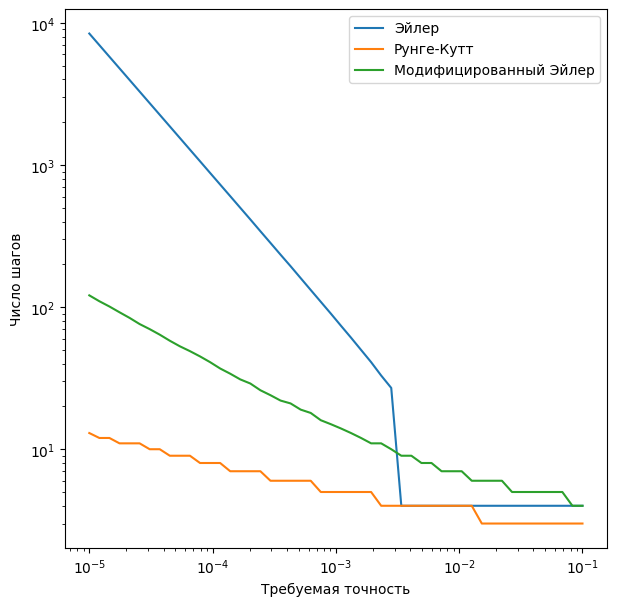

In [5]:
alpha = -5
f = (lambda y:alpha*y, lambda y: alpha)
yExact = lambda t: np.exp(alpha*t)

eps=np.finfo(float).eps

def Err(f, y, integrator, N, t_1 = 1): # ошибка интегрирования на всем интервале
  y0 = y(0)
  y1 = y(t_1)
  y_approx = integrate(N, t_1/N, f, y0, integrator)
  err = np.maximum(np.abs(y_approx-y1), eps)
  return err

def CountSteps(f, y, integrator, err): #количество шагов, необходимое для достижения заданной точности
  N = 1
  while err<=Err(f,y,integrator, N):
    N+=1
  return N

errors = np.logspace(-5,-1, 50)

fig, (ax1) = plt.subplots(ncols=1, nrows=1, figsize=(7,7))

ax1.loglog(errors, [CountSteps(f[0], yExact, EulerIntegrator, err) for err in errors], label = 'Эйлер')
ax1.loglog(errors, [CountSteps(f[0], yExact, RungeKuttaIntegrator, err) for err in errors], label = 'Рунге-Кутт')
ax1.loglog(errors, [CountSteps(f[0], yExact, ModifiedEulerIntegrator, err) for err in errors], label = 'Модифицированный Эйлер')
ax1.set_xlabel('Требуемая точность')
ax1.set_ylabel('Число шагов')

plt.legend()
plt.show()

## Задание 3:

В виду того что Метод Эйлера менее устойчив, чем метод Рунге-Кутта. Поэтому метод Рунге-Кутта выгоднее использовать

## Задание 4:

В данном численном эксперименте по графику видно, что минимум ошибки достигается примерно при шаге порядка $10^{−10}$ для метода Эйлера и порядка $10^{−4}$ для метода Рунге–Кутты 4-го порядка. При увеличении шага начинают доминировать ошибки округления.

In [6]:
def ModifiedEulerIntegrator(h,y0,f):
    """
    Модифицированный метод Эйлера.
    Аргументы аналогичны EulerIntegrator.
    """
    yIntermediate=y0+f(y0)*h/2
    return y0+h*f(yIntermediate)

def EulerIntegrator(h,y0,f):
    """
    Делает один шаг методом Эйлера.
    y0 - начальное значение решения в момент времени t=0,
    h - шаг по времения,
    f(y) - правая часть дифференциального уравнения.
    Возвращает приближенное значение y(h).
    """
    return y0+h*f(y0)

def RungeKuttaIntegrator(h,y0,f):
    """
    Классический метод Рунге-Кутты четвертого порядка.
    Аргументы аналогичны EulerIntegrator.
    """
    k1=f(y0)
    k2=f(y0+k1*h/2)
    k3=f(y0+k2*h/2)
    k4=f(y0+k3*h)
    return y0+(k1+2*k2+2*k3+k4)*h/6

def integrate(N, delta, f, y0, integrator):
    """
    Делает N шагов длины delta метода integrator для уравнения y'=f(y) с начальными условиями y0.
    Возвращает значение решения в конце интервала.
    """
    for n in range(N):
        y0=integrator(delta, y0, f)
    return y0

import scipy.optimize
def BackwardEulerIntegrator(h,y0,f):
    """
    Неявный метод Эйлера.
    Аргументы аналогичны NewtonIntegrator.
    """
    def G(v): return y0-v+h*f[0](v)
    def Gprime(v): return h*f[1](v)-np.ones(v.shape) # Производная функции G
    return scipy.optimize.newton(G,y0,fprime=Gprime) # Запускаем итерации метода Ньютона, используя y0 в качестве первого приближения.

def intervalErrorPlot(f, y, integrator, T=1, maxNumberOfSteps=1000, numberOfPointsOnPlot=16):
    """
    Рисует график зависимости погрешности интегрирования на интервале
    от длины шага интегрирвания.
    Аргументы повторяют аргументы oneStepErrorPlot.
    """
    eps=np.finfo(float).eps
    numberOfSteps=np.logspace(0,np.log10(maxNumberOfSteps),numberOfPointsOnPlot).astype(int)
    steps=T/numberOfSteps # шаги интегрирования
    y0=y(0) # начальное значение
    yPrecise=y(T) # точнре значения решения на правом конце
    yApproximate=[integrate(N,T/N,f,y0,integrator) for N in numberOfSteps] # приближенные решения
    h=[np.maximum(np.max(np.abs(yPrecise-ya)),eps) for ya in yApproximate]
    plt.loglog(steps, h, '.-')
    plt.xlabel("Шаг интегрирования")
    plt.ylabel("Погрешность интегрования на интервале")

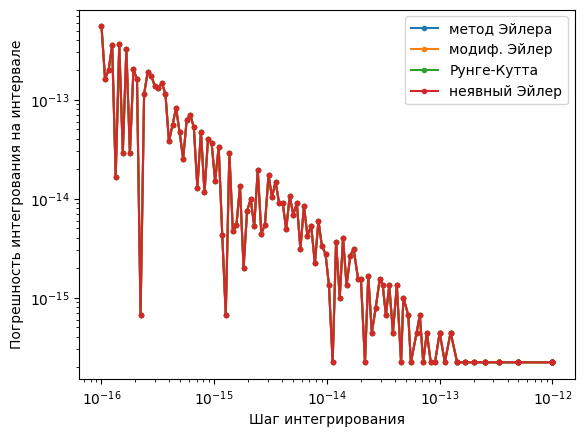

In [7]:
Numb=1e4
T=1e-12
intervalErrorPlot(f[0], yExact, EulerIntegrator,T=T, maxNumberOfSteps=Numb,numberOfPointsOnPlot=128)
intervalErrorPlot(f[0], yExact, ModifiedEulerIntegrator,T=T,maxNumberOfSteps=Numb, numberOfPointsOnPlot=128)
intervalErrorPlot(f[0], yExact, RungeKuttaIntegrator,T=T,maxNumberOfSteps=Numb,numberOfPointsOnPlot=128)
intervalErrorPlot(f, yExact, BackwardEulerIntegrator,T=T,maxNumberOfSteps=Numb, numberOfPointsOnPlot=128)

plt.legend([u"метод Эйлера",u"модиф. Эйлер",u"Рунге-Кутта",u"неявный Эйлер",u"первый порядок"])
plt.show()

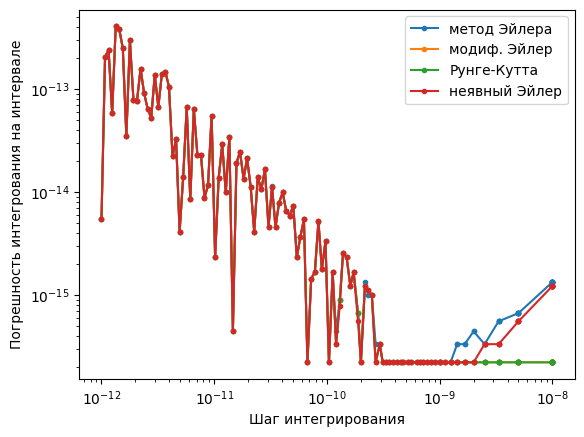

In [8]:
Numb=1e4
T=1e-8
intervalErrorPlot(f[0], yExact, EulerIntegrator,T=T, maxNumberOfSteps=Numb,numberOfPointsOnPlot=128)
intervalErrorPlot(f[0], yExact, ModifiedEulerIntegrator,T=T,maxNumberOfSteps=Numb, numberOfPointsOnPlot=128)
intervalErrorPlot(f[0], yExact, RungeKuttaIntegrator,T=T,maxNumberOfSteps=Numb,numberOfPointsOnPlot=128)
intervalErrorPlot(f, yExact, BackwardEulerIntegrator,T=T,maxNumberOfSteps=Numb, numberOfPointsOnPlot=128)

plt.legend([u"метод Эйлера",u"модиф. Эйлер",u"Рунге-Кутта",u"неявный Эйлер",u"первый порядок"])
plt.show()

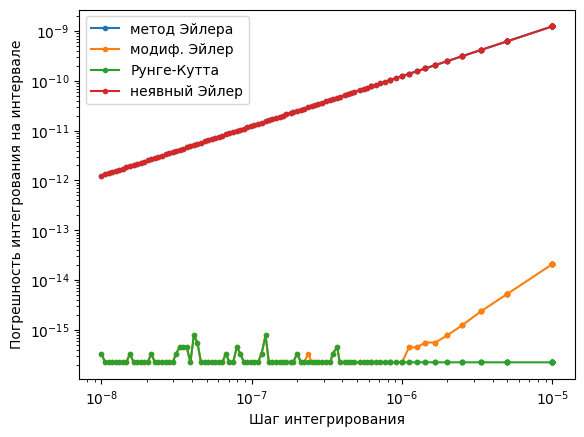

In [9]:
Numb=1e3
T=1e-5
intervalErrorPlot(f[0], yExact, EulerIntegrator,T=T, maxNumberOfSteps=Numb,numberOfPointsOnPlot=128)
intervalErrorPlot(f[0], yExact, ModifiedEulerIntegrator,T=T,maxNumberOfSteps=Numb, numberOfPointsOnPlot=128)
intervalErrorPlot(f[0], yExact, RungeKuttaIntegrator,T=T,maxNumberOfSteps=Numb,numberOfPointsOnPlot=128)
intervalErrorPlot(f, yExact, BackwardEulerIntegrator,T=T,maxNumberOfSteps=Numb, numberOfPointsOnPlot=128)

plt.legend([u"метод Эйлера",u"модиф. Эйлер",u"Рунге-Кутта",u"неявный Эйлер",u"первый порядок"])
plt.show()

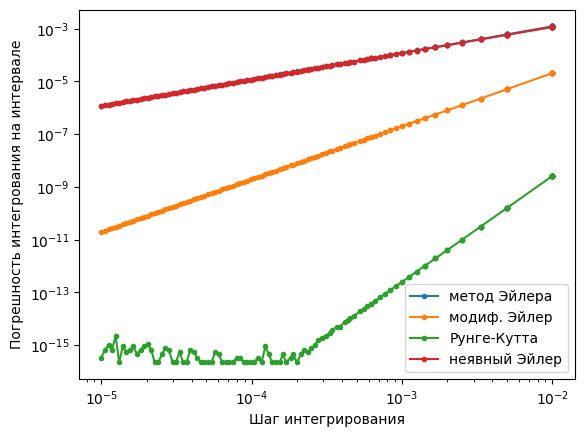

In [10]:
Numb=1e3
T=1e-2
intervalErrorPlot(f[0], yExact, EulerIntegrator,T=T, maxNumberOfSteps=Numb,numberOfPointsOnPlot=128)
intervalErrorPlot(f[0], yExact, ModifiedEulerIntegrator,T=T,maxNumberOfSteps=Numb, numberOfPointsOnPlot=128)
intervalErrorPlot(f[0], yExact, RungeKuttaIntegrator,T=T,maxNumberOfSteps=Numb,numberOfPointsOnPlot=128)
intervalErrorPlot(f, yExact, BackwardEulerIntegrator,T=T,maxNumberOfSteps=Numb, numberOfPointsOnPlot=128)

plt.legend([u"метод Эйлера",u"модиф. Эйлер",u"Рунге-Кутта",u"неявный Эйлер",u"первый порядок"])
plt.show()